# Linear Models

Check the performance of SVM and logistic regression on our engineered data sets before moving to more complex models.

In [ ]:
%reload_ext autoreload
%autoreload 2
import sys, os
import pandas as pd
import warnings
import numpy as np
from sklearn.model_selection import train_test_split
from pathlib import Path

warnings.filterwarnings('ignore')
DATA_DIR = Path('../src/shared_util/data')
METRICS_DIR = DATA_DIR
CSV_PATH = METRICS_DIR / 'metrics.csv'
LOG = True



from shared_util.metrics import metrics_db
from shared_util.dataio import load_csv



if LOG:
    metrics_db.read_in(CSV_PATH)

METRICS_DB_ID = 0 # update this to not overwrite previous metrics for these models
METRIC_NOTES = "first pass" # global metric notes for this run



,id,model,data,threshold notes,pipeline_notes,hyperparam_notes,notes,roc_auc,accuracy,precision,recall,f1,TN,TP,FP,FN
0,0,rf,train,base,under_sample,NaN,NaN,0.645700,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,rf,train,base,SMOTE,NaN,NaN,0.590117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,rf,validate,base,under_sample,tuned_best_roc_auc,NaN,0.661655,0.624958,0.174760,0.622353,0.272891,8337.0,1058.0,4996.0,642.0
3,0,rf+int,validate,base,under_sample,tuned_best_roc_auc,NaN,0.661511,0.623894,0.173439,0.617647,0.270828,8329.0,1050.0,5004.0,650.0
4,0,rf,test,f2_weighted,under_sample,tuned_best_roc_auc,NaN,0.661281,0.533965,0.167305,0.716238,0.271250,6755.0,1310.0,6520.0,519.0


In [25]:
df = load_csv('cleaned')
df.head()

,encounter_id,patient_nbr,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,medical_specialty,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,target
0,2278392,8222157,Caucasian,Female,[0-10),6,25,1,1,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,No,0
1,149190,55629189,Caucasian,Female,[10-20),1,1,7,3,?,...,No,Up,No,No,No,No,No,Ch,Yes,0
2,64410,86047875,AfricanAmerican,Female,[20-30),1,1,7,2,?,...,No,No,No,No,No,No,No,No,Yes,0
3,500364,82442376,Caucasian,Male,[30-40),1,1,7,2,?,...,No,Up,No,No,No,No,No,Ch,Yes,0
4,16680,42519267,Caucasian,Male,[40-50),1,1,7,1,?,...,No,Steady,No,No,No,No,No,Ch,Yes,0


In [ ]:
from shared_util.split import group_split

X_train, X_validate, X_test, y_train, y_validate, y_test = group_split(df)

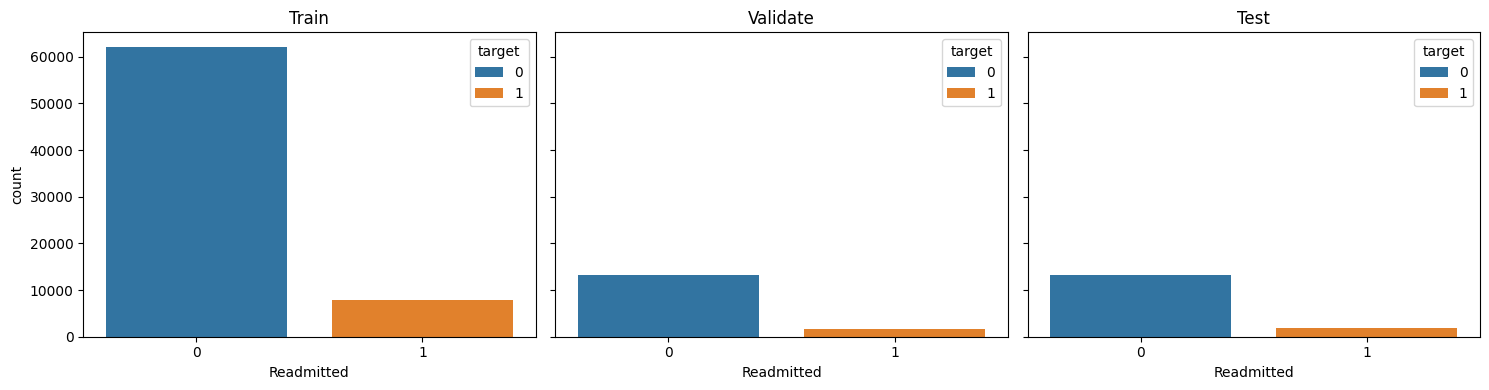

In [31]:
from shared_util.metrics.printing import check_y_dist

check_y_dist(
    y_train,
    y_validate,
    y_test
)

In [5]:
# from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold

# def make_cv():
#     return StratifiedKFold(
#     n_splits=10,
#     shuffle=True,
#     random_state=42
#     )


## Baseline Logistic Regression

In [32]:
from sklearn.linear_model import SGDClassifier
from imblearn.under_sampling import RandomUnderSampler
from sklearn.preprocessing import StandardScaler
from shared_util.pipeline import CleaningPipeline

from shared_util.baseline import get_baseline_score
from imblearn.pipeline import Pipeline


print('Baseline SGD Classifier')

roc_auc = get_baseline_score(
    SGDClassifier(random_state=42),
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler(),
    preprocessor=CleaningPipeline(create_interactions=True)
    )


if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        model='sgd',
        threshold_notes='base',
        data='train',
        pipeline_notes='under_sample',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )



Baseline SGD Classifier
roc_auc score per fold:  [0.61177379 0.59063554 0.5841329  0.58344882 0.58964122]
mean roc_auc score:  0.5919264556358319
logged row: (0, sgd, train, base, under_sample)


In [33]:
# try SMOTE
from imblearn.over_sampling import SMOTE

print('Baseline ROC_AUC using SMOTE')

roc_auc = get_baseline_score(
    SGDClassifier(random_state=42),
    SMOTE(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler(),
    preprocessor=CleaningPipeline(create_interactions=True)
    )

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        threshold_notes='base',
        data='train',
        model='sgd',
        pipeline_notes='SMOTE',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )


Baseline ROC_AUC using SMOTE
roc_auc score per fold:  [0.56549639 0.55717375 0.55336954 0.54818937 0.53716122]
mean roc_auc score:  0.5522780530409328
logged row: (0, sgd, train, base, SMOTE)


In [34]:
def make_base_sgd(use_smote=False):
    return Pipeline([
        ('preprocessor', CleaningPipeline(create_interactions=True)),
        ('sampler',SMOTE(random_state=42) if use_smote else RandomUnderSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', SGDClassifier(random_state=42))
    ])

In [35]:
# hyperparam search for SGD
from sklearn.model_selection import RandomizedSearchCV
from shared_util.baseline import make_group_cv


sgd_param_grid = {
    "model__loss": ["log_loss", "modified_huber", "hinge", "squared_hinge"],
    "model__penalty": ["l2", "l1", "elasticnet"],
    "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
    "model__l1_ratio": [0.1, 0.5, 0.9],
    "model__learning_rate": ["constant", "optimal", "invscaling", "adaptive"],
    "model__eta0": [1e-4, 3e-4, 1e-3, 3e-3, 1e-2, 3e-2, 1e-1],
    "model__max_iter": [100, 500, 1000],
    "model__tol": [1e-3, 1e-4],
    "model__class_weight": [None, "balanced"],
    "model__average": [False, True, 5, 10],
    "model__shuffle": [True],
}

rs = RandomizedSearchCV(
    estimator=make_base_sgd(),
    param_distributions=sgd_param_grid,
    n_iter=30,
    scoring='roc_auc',
    cv=make_group_cv(),
    n_jobs=-1,
    random_state=42,
    refit=True
)

rs.fit(X_train, y_train, groups=X_train['patient_nbr'])

print(f'Best ROC_AUC (cv): {rs.best_score_}')
print(f'best params: {rs.best_params_}')

res_df = pd.DataFrame(
    rs.cv_results_
).sort_values('rank_test_score').reset_index(drop=True)
res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

Best ROC_AUC (cv): 0.653563506494875
best params: {'model__tol': 0.0001, 'model__shuffle': True, 'model__penalty': 'l1', 'model__max_iter': 500, 'model__loss': 'modified_huber', 'model__learning_rate': 'invscaling', 'model__l1_ratio': 0.9, 'model__eta0': 0.003, 'model__class_weight': None, 'model__average': 10, 'model__alpha': 0.001}


,rank_test_score,mean_test_score,std_test_score,params
0,1,0.653564,0.006716,"{'model__tol': 0.0001, 'model__shuffle': True,..."
1,2,0.653363,0.007861,"{'model__tol': 0.001, 'model__shuffle': True, ..."
2,3,0.652808,0.007575,"{'model__tol': 0.001, 'model__shuffle': True, ..."
3,4,0.652529,0.007283,"{'model__tol': 0.001, 'model__shuffle': True, ..."
4,5,0.652124,0.007238,"{'model__tol': 0.001, 'model__shuffle': True, ..."
5,6,0.651830,0.007097,"{'model__tol': 0.0001, 'model__shuffle': True,..."
6,7,0.651200,0.006918,"{'model__tol': 0.001, 'model__shuffle': True, ..."
7,8,0.650755,0.007077,"{'model__tol': 0.0001, 'model__shuffle': True,..."
8,9,0.645260,0.006564,"{'model__tol': 0.0001, 'model__shuffle': True,..."
9,10,0.644487,0.006217,"{'model__tol': 0.0001, 'model__shuffle': True,..."


In [10]:
# Best ROC_AUC (cv): 0.6549746228889155
# best params: {'model__tol': 0.001, 'model__shuffle': True, 'model__penalty': 'l1', 'model__max_iter': 1000, 'model__loss': 'log_loss', 'model__learning_rate': 'constant', 'model__l1_ratio': 0.1, 'model__eta0': 0.0003, 'model__class_weight': 'balanced', 'model__average': False, 'model__alpha': 0.0001}

In [36]:
# predict on validate set before threshold changes
from shared_util.metrics.scoring import get_scores, best_threshold_by_fbeta, plot_scoring
from shared_util.metrics.printing import print_metrics

sgd_est = rs.best_estimator_
sgd_scores = get_scores(sgd_est, X_validate)

y_pred = rs.best_estimator_.predict(X_validate) #type: ignore

print_metrics(
              y_true=y_validate, 
              y_pred=y_pred, 
              y_proba=sgd_scores,
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              data='validate',
              model='sgd',
              hyperparam_notes='tuned best roc',
              pipeline_notes='under_sample',
              log=LOG
)



ROC_AUC:     0.650411186750257
Accuracy:      0.661544601875873
F1 score:      0.2645273200346921
Precision:     0.1753545419701035
Recall:        0.538235294117647

Confusion matrix:

TN: 9030, FP: 4303, FN: 785, TP: 915

Classification report:
               precision    recall  f1-score   support

           0       0.92      0.68      0.78     13333
           1       0.18      0.54      0.26      1700

    accuracy                           0.66     15033
   macro avg       0.55      0.61      0.52     15033
weighted avg       0.84      0.66      0.72     15033

logged row: (0, sgd, validate, base, under_sample)


Best threshold (F2): 0.4311
Precision: 0.150  Recall: 0.764  F2: 0.420


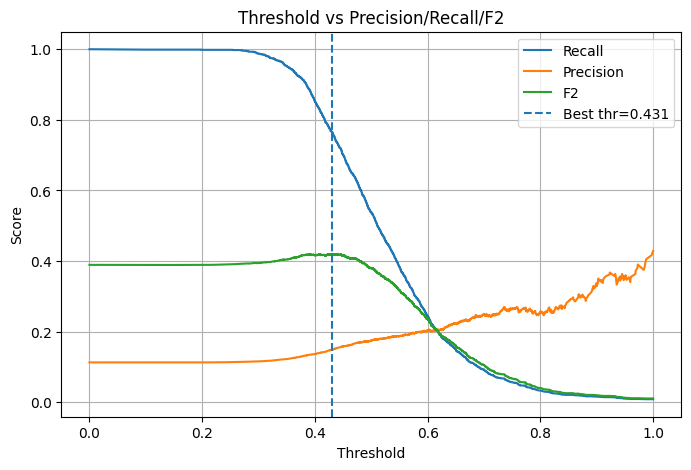

In [37]:
# decide threshold on validation set
info = best_threshold_by_fbeta(y_validate, sgd_scores, beta=2.0)
best_thresh = info['threshold']
y_pred_custom = (sgd_scores >= best_thresh).astype(int)

print(f"Best threshold (F2): {best_thresh:.4f}")
print(f"Precision: {info['precision']:.3f}  Recall: {info['recall']:.3f}  F2: {info['fbeta']:.3f}")

plot_scoring(info['curve'])

In [38]:
# use the threshold for predicitons on the held out test set

from shared_util.metrics.printing import print_metrics

sgd_scores_test = get_scores(sgd_est, X_test)

y_pred_custom_test = (sgd_scores_test >= best_thresh).astype(int)

print_metrics(
    y_true=y_test,
    y_pred=y_pred_custom_test,
    y_proba=sgd_scores_test,
    data='test',
    threshold_notes='f2_weighted',
    metrics_db_id=METRICS_DB_ID,
    metrics_notes=METRIC_NOTES,
    log=LOG,
    model='sgd',
    hyperparam_notes='tuned best ROC',
    pipeline_notes='under_sample'

)

ROC_AUC:     0.6524219032350733
Accuracy:      0.4764962923728814
F1 score:      0.2597135099709765
Precision:     0.15668775417984637
Recall:        0.758337889557135

Confusion matrix:

TN: 5810, FP: 7465, FN: 442, TP: 1387

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.44      0.60     13275
           1       0.16      0.76      0.26      1829

    accuracy                           0.48     15104
   macro avg       0.54      0.60      0.43     15104
weighted avg       0.84      0.48      0.55     15104

logged row: (0, sgd, test, f2_weighted, under_sample)


In [39]:
# SVM
from sklearn.svm import SVC
from shared_util.baseline import get_baseline_score

roc_auc = get_baseline_score(
    SVC(random_state=42),
    RandomUnderSampler(random_state=42),
    X_train,
    y_train,
    scaler=StandardScaler(),
    preprocessor=CleaningPipeline(create_interactions=True)
)

if LOG:
    metrics_db.log_metric(
        metric_id=METRICS_DB_ID,
        threshold_notes='base',
        data='train',
        model='svc',
        pipeline_notes='under_sample',
        notes=METRIC_NOTES,
        roc_auc=roc_auc
    )






roc_auc score per fold:  [0.65131697 0.64605127 0.6405608  0.63545184 0.66097065]
mean roc_auc score:  0.6468703052623719
logged row: (0, svc, train, base, under_sample)


In [15]:
# running smote did not get a result after 6 hours so leaving it out for now

## Hyperparameter sweep for SVM

In [40]:
# this cell takes a very long time to run
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingRandomSearchCV #type: ignore
from scipy.stats import loguniform
from sklearn.model_selection import StratifiedGroupKFold





def make_base_svc(model=None):
    return Pipeline([
        ('preprocessor', CleaningPipeline(create_interactions=True)),
        ('sampler', RandomUnderSampler(random_state=42)),
        ('scaler', StandardScaler()),
        ('model', model if model != None else SVC(random_state=42, cache_size=16384))
    ])
# limited param search due to computation time
svc_param_grid = {
    "model__kernel": ["rbf"],
    "model__C": loguniform(1e-3, 1e3),
    "model__gamma": [0.001, 0.01, 0.1, 1],
    "model__class_weight": ["balanced"],
    "model__shrinking": [False],
}

# reduced to 5 folds again for computation time

cv_svc = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

rs_hsvc = RandomizedSearchCV(
    estimator=make_base_svc(),
    param_distributions=svc_param_grid,
   # n_iter=50,  
    scoring='roc_auc',
    cv=cv_svc,
    n_jobs=-1,
    random_state=42,
    refit=True,
    verbose=2
)



rs_hsvc.fit(X_train, y_train, groups=X_train['patient_nbr'])

print(f'Best ROC_AUC (cv): {rs_hsvc.best_score_}')
print(f'Best params: {rs_hsvc.best_params_}')

res_df = pd.DataFrame(rs_hsvc.cv_results_).sort_values('rank_test_score').reset_index(drop=True)
res_df[['rank_test_score','mean_test_score','std_test_score','params']].head(10)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


KeyboardInterrupt: 

In [17]:
# The above code block generates best hyperparams for our SVC model:
# Best ROC_AUC (cv): 0.6457530427983966
# Best params: {'model__C': np.float64(0.1767016940294795), 'model__class_weight': 'balanced', 'model__gamma': 0.001, 'model__kernel': 'rbf', 'model__shrinking': False}

In [42]:
# predict on validate set before threshold changes
# allows you to skip the above cell with pre computed best hyperparams
try:
    svm_est = rs_hsvc.best_estimator_
except:
    svm_est = make_base_svc(SVC(
        C=float(0.1767016940294795),
        class_weight='balanced',
        gamma=0.001,
        kernel='rbf',
        shrinking=False
    ))
    svm_est.fit(X_train, y_train)

In [ ]:
svm_scores = get_scores(svm_est, X_validate)

y_pred = svm_est.predict(X_validate) #type: ignore

print_metrics(
              y_true=y_validate, 
              y_pred=y_pred, 
              y_proba=svm_scores,
              data='validate',
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='svc',
              hyperparam_notes='tuned best roc',
              pipeline_notes='under_sample',
              log=LOG
)



ROC_AUC:     0.6460464305725292
Accuracy:      0.7126987294618506
F1 score:      0.2503037667071689
Precision:     0.17754247722235902
Recall:        0.42411764705882354

Confusion matrix:

TN: 9993, FP: 3340, FN: 979, TP: 721

Classification report:
               precision    recall  f1-score   support

           0       0.91      0.75      0.82     13333
           1       0.18      0.42      0.25      1700

    accuracy                           0.71     15033
   macro avg       0.54      0.59      0.54     15033
weighted avg       0.83      0.71      0.76     15033

logged row: (0, svc, validate, base, under_sample)


Best threshold (F2): -0.7481
Precision: 0.147  Recall: 0.791  F2: 0.422


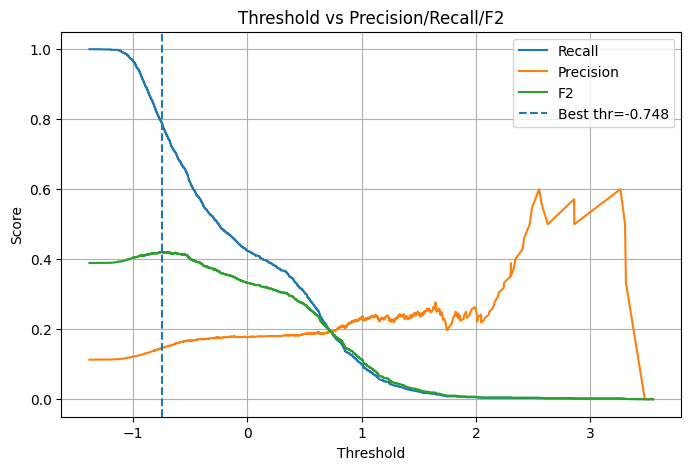

In [44]:
# threshold sweep using validation set
from shared_util.metrics.scoring import get_scores, best_threshold_by_fbeta, plot_scoring



info = best_threshold_by_fbeta(y_validate, svm_scores, beta=2.0)

best_thresh = info["threshold"]
y_pred_custom = (svm_scores >= best_thresh).astype(int)

print(f"Best threshold (F2): {best_thresh:.4f}")
print(f"Precision: {info['precision']:.3f}  Recall: {info['recall']:.3f}  F2: {info['fbeta']:.3f}")

plot_scoring(info['curve'])

In [45]:
# held out test prediction using calculated threshold

# this inference took ~25 seconds, considering other models took <1 second, thats a significant downside to SVC

svm_scores_test = get_scores(svm_est, X_test)

y_pred_test_svm = (svm_scores_test >= best_thresh).astype(int)


In [46]:
from shared_util.metrics.printing import print_metrics

print ('Held out test metrics for (Support Vector Classifier)')

print_metrics(
              y_true=y_test, 
              y_pred=y_pred_test_svm, 
              y_proba=svm_scores_test,
              data='test',
              threshold_notes='f2_weighted',
              metrics_db_id=METRICS_DB_ID,
              metrics_notes=METRIC_NOTES,
              model='svc',
              hyperparam_notes='tuned best roc, uses HalvingRandomSearchCV',
              pipeline_notes='under_sample',
              log=LOG
              )

Held out test metrics for (Support Vector Classifier)
ROC_AUC:     0.6418085479906795
Accuracy:      0.4531912076271186
F1 score:      0.2594817537882184
Precision:     0.1551909051909052
Recall:        0.7911427009294697

Confusion matrix:

TN: 5398, FP: 7877, FN: 382, TP: 1447

Classification report:
               precision    recall  f1-score   support

           0       0.93      0.41      0.57     13275
           1       0.16      0.79      0.26      1829

    accuracy                           0.45     15104
   macro avg       0.54      0.60      0.41     15104
weighted avg       0.84      0.45      0.53     15104

logged row: (0, svc, test, f2_weighted, under_sample)


Both SVM and the SGD classifier both achieved above expected results compared to previous literature, which showed linear models performing, generally, with a ROC_AUC below 0.600.



In [ ]:
metrics_db.close(write=True) # remove the db dataframe from memory to prevent weirdness when running multiple notebooks